## Project Title

Email Spam Classification Using Perceptron Algorithm

Goal

Develop a machine learning model that classifies emails into:

- Ham (Legitimate Email)
- Spam (Unwanted Email)

using the Perceptron Algorithm.

In [ ]:
# Import Required Libraries

In [45]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string
import nltk

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [46]:
# Download NLTK Resources

In [38]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Load the Dataset

In [47]:
df = pd.read_csv("spam_ham_dataset.csv")

In [48]:
# Display the first 5 rows of the DataFrame to examine the data structure and content
df.head()

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [49]:
print("Dataset Shape:", df.shape)

Dataset Shape: (193852, 2)


In [6]:
df.sample(5)

,label,text
12985,Spam,hi there lovely this kind of opportunity comes...
5326,Ham,"outstanding , cindy . thank you so much . i wi..."
61861,Spam,the facts . . .\ndeep in canada ' s barren nor...
162377,Ham,subscribe change profile contact us long term ...
63042,Ham,that makes you an eve bigger brat original mes...


In [50]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193852 entries, 0 to 193851
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   193852 non-null  str  
 1   text    193850 non-null  str  
dtypes: str(2)
memory usage: 3.0 MB


In [51]:
df.describe(include='all')

,label,text
count,193852,193850
unique,2,193848
top,Ham,hi
freq,102160,2


In [52]:
df.isnull().sum()

label    0
text     2
dtype: int64

In [53]:
df.dropna(inplace=True)

In [54]:
# Count the total number of duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(0)

In [55]:
df.columns

Index(['label', 'text'], dtype='str')

In [56]:
# Explore the Target Variable
df['label'].value_counts()

label
Ham     102159
Spam     91691
Name: count, dtype: int64

# Visualize Class Distribution

In [ ]:
# Count Plot

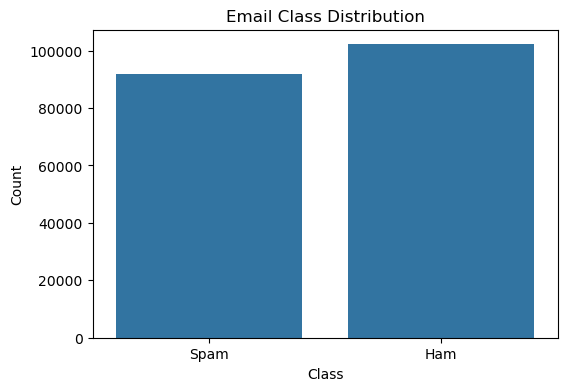

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Email Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
# Pie Chart

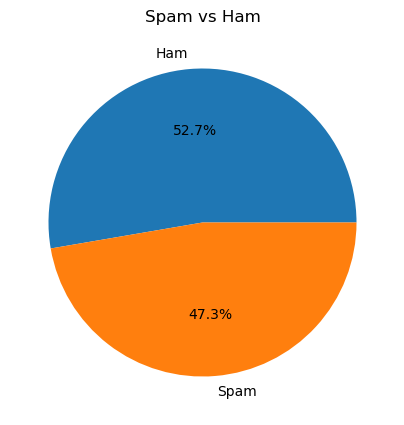

In [58]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5)
)

plt.ylabel("")
plt.title("Spam vs Ham")
plt.show()

In [ ]:
# Convert Labels into Numbers

In [59]:
df['label'] = df['label'].map({
    'Ham':0,
    'Spam':1
})

In [60]:
df.head()

,label,text
0,1,viiiiiiagraaaa\nonly for the ones that want to...
1,0,got ice thought look az original message ice o...
2,1,yo ur wom an ne eds an escapenumber in ch ma n...
3,1,start increasing your odds of success & live s...
4,0,author jra date escapenumber escapenumber esca...


In [61]:
df.info()

<class 'pandas.DataFrame'>
Index: 193850 entries, 0 to 193851
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   193850 non-null  int64
 1   text    193850 non-null  str  
dtypes: int64(1), str(1)
memory usage: 4.4 MB


# Exploratory Data Analysis (EDA)

In [ ]:
# Create New Features

In [62]:
# Character Count
df['char_count'] = df['text'].apply(len)

# Word Count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Sentence Count
df['sentence_count'] = df['text'].apply(lambda x: len(x.split('.')))

In [63]:
df.head()

,label,text,char_count,word_count,sentence_count
0,1,viiiiiiagraaaa\nonly for the ones that want to...,403,60,6
1,0,got ice thought look az original message ice o...,530,60,1
2,1,yo ur wom an ne eds an escapenumber in ch ma n...,215,48,1
3,1,start increasing your odds of success & live s...,345,69,5
4,0,author jra date escapenumber escapenumber esca...,3097,467,1


In [ ]:
# Statistical Summary

In [64]:
df[['char_count','word_count','sentence_count']].describe()

,char_count,word_count,sentence_count
count,1.938500e+05,1.938500e+05,193850.000000
mean,1.812779e+03,2.760373e+02,3.335517
std,2.659510e+04,3.671773e+03,19.266957
min,1.000000e+00,1.000000e+00,1.000000
25%,3.620000e+02,5.500000e+01,1.000000
50%,8.000000e+02,1.270000e+02,1.000000
75%,1.803000e+03,2.800000e+02,1.000000
max,1.151031e+07,1.585483e+06,2732.000000


In [ ]:
# Compare Ham vs Spam

In [65]:
df.groupby('label')[['char_count','word_count','sentence_count']].mean()

,char_count,word_count,sentence_count
label,,,
0,2169.722912,334.573498,3.505702
1,1415.085112,210.818314,3.145903


In [ ]:
# Distribution of Character Count

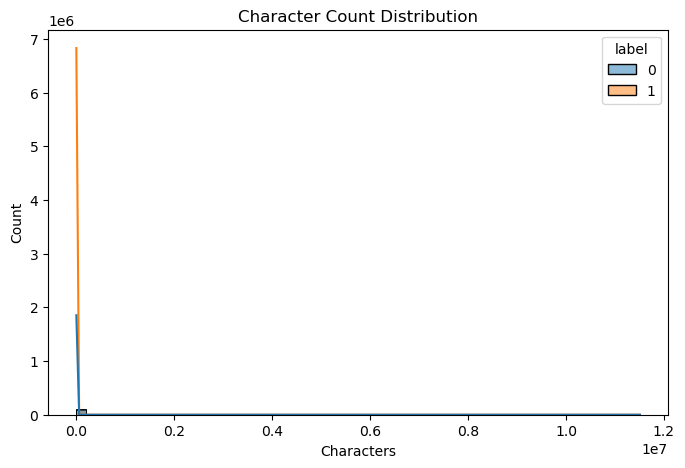

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='char_count',
    hue='label',
    bins=60,
    kde=True
)

plt.title("Character Count Distribution")
plt.xlabel("Characters")
plt.show()

In [ ]:
# Distribution of Word Count

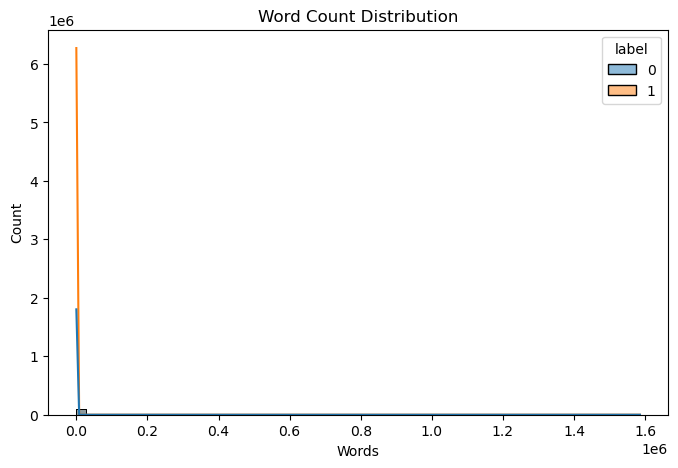

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='word_count',
    hue='label',
    bins=60,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.show()

In [ ]:
# Distribution of Sentence Count

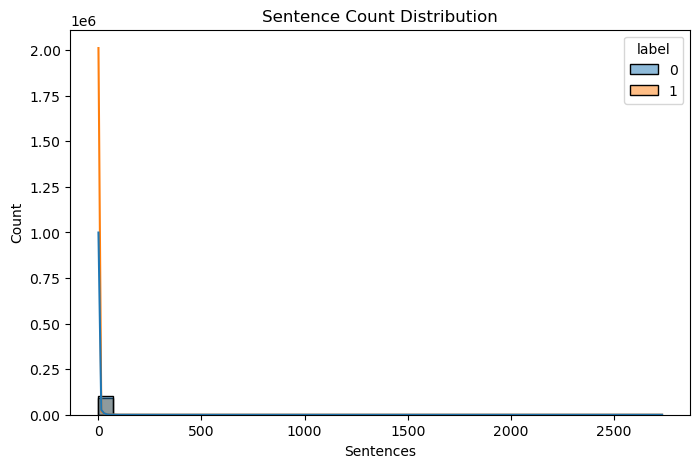

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='sentence_count',
    hue='label',
    bins=40,
    kde=True
)

plt.title("Sentence Count Distribution")
plt.xlabel("Sentences")
plt.show()

In [ ]:
# Boxplots

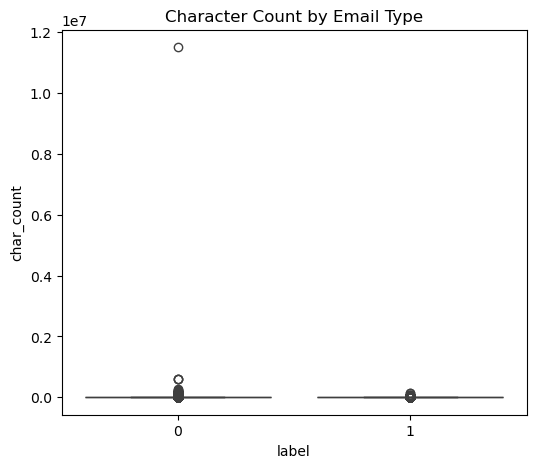

In [69]:
# Character Count
plt.figure(figsize=(6,5))

sns.boxplot(
    x='label',
    y='char_count',
    data=df
)

plt.title("Character Count by Email Type")
plt.show()

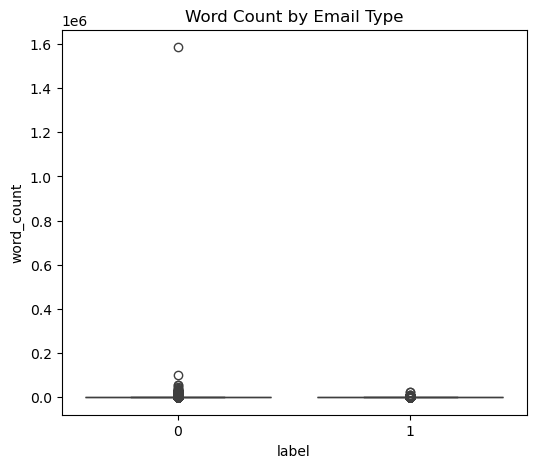

In [70]:
# Word Count
plt.figure(figsize=(6,5))

sns.boxplot(
    x='label',
    y='word_count',
    data=df
)

plt.title("Word Count by Email Type")
plt.show()

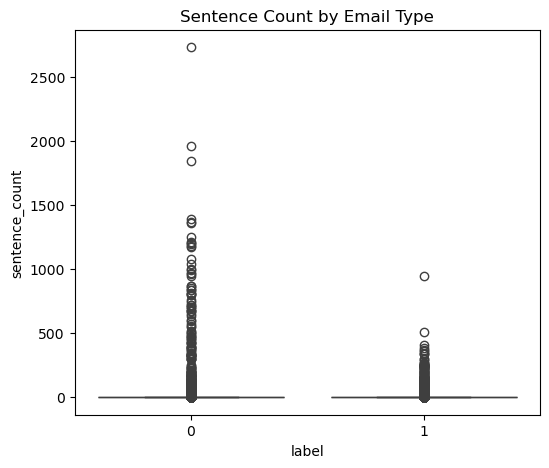

In [71]:
# Sentence Count
plt.figure(figsize=(6,5))

sns.boxplot(
    x='label',
    y='sentence_count',
    data=df
)

plt.title("Sentence Count by Email Type")
plt.show()

In [ ]:
# Correlation Between Features

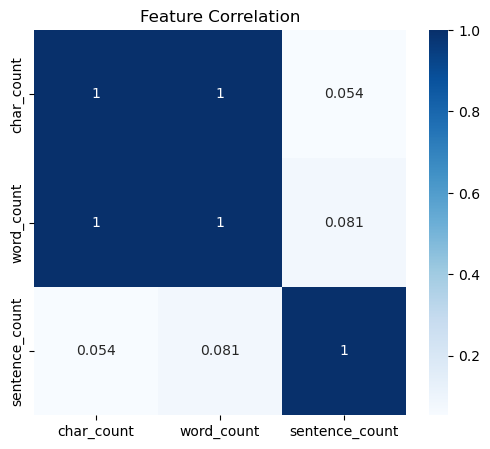

In [72]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[['char_count','word_count','sentence_count']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Feature Correlation")
plt.show()

# Text Preprocessing

In [73]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [74]:
# Creates the required objects

In [75]:
# English stopwords
stop_words = set(stopwords.words('english'))

# Lemmatizer
lemmatizer = WordNetLemmatizer()

In [76]:
# Creates the Preprocessing Function

In [158]:
import re
import string

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into a sentence
    return " ".join(words)

In [159]:
# Test the Function

In [160]:
sample_email = df['text'].iloc[0]

print("Original Email:\n")
print(sample_email)

print("\n" + "="*80 + "\n")

print("Processed Email:\n")
print(preprocess_text(sample_email))

Original Email:

viiiiiiagraaaa
only for the ones that want to make her scream .
prodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate ponce bernie cox angeles impassive circulate impend miscellany chalkboard whizzing pend armenian cutlet waring makeshift fletch dispel crest cadet dovetail rapprochement gerry bayreuth selectman wilmington tuttle alchemy itt bullyboy .
caan ' t do . . .



Processed Email:

viiiiiiagraaaa one want make scream prodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate ponce bernie cox angeles impassive circulate impend miscellany chalkboard whizzing pend armenian cutlet waring makeshift fletch dispel crest cadet dovetail rapprochement gerry bayreuth selectman wilmington tuttle alchemy itt bullyboy caan


In [161]:
# Apply the Function to the Entire Dataset

In [162]:
df['clean_text'] = df['text'].apply(preprocess_text)

In [163]:
# Verify the Results

In [164]:
df[['text', 'clean_text']].head()

,text,clean_text
0,viiiiiiagraaaa\nonly for the ones that want to...,viiiiiiagraaaa one want make scream prodigy sc...
1,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom ne ed escapenumber ch n b e th n f h...
3,start increasing your odds of success & live s...,start increasing odds success live sexually he...
4,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


In [165]:
# Check for Empty Emails
(df['clean_text'].str.len() == 0).sum()

np.int64(0)

In [166]:
df = df[df['clean_text'].str.len() > 0]

In [167]:
df.reset_index(drop=True, inplace=True)

In [168]:
# Saves the Cleaned Dataset

In [169]:
df.to_csv("cleaned_email_dataset.csv", index=False)

# Feature Engineering (TF-IDF)

In [170]:
# Import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [171]:
# Create the Vectorizer

In [172]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [173]:
# Transform the Text

In [174]:
X = tfidf.fit_transform(df['clean_text'])

In [175]:
# target variable
y = df['label']

In [176]:
# Check the Shapes
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (193812, 10000)
Target Shape: (193812,)


In [177]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 10000


In [178]:
# View Some Feature Names
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aa' 'aa ba' 'aa escapenumber' 'aaaa' 'aaaa escapelong' 'aaron' 'ab'
 'ab bescapenumber' 'ab escapenumber' 'abandoned' 'abbott' 'abc' 'ability'
 'able' 'able get' 'able play' 'abroad' 'absence' 'absolute' 'absolutely'
 'abstract' 'abuse' 'ac' 'ac aescapenumber' 'ac bescapenumber'
 'ac escapenumber' 'ac uk' 'academic' 'academy' 'accenture' 'accept'
 'acceptable' 'acceptance' 'acceptance company' 'acceptance create'
 'acceptance term' 'accepted' 'accepting' 'access' 'accessible'
 'accessing' 'accessory' 'accident' 'accommodation' 'accomplish' 'accord'
 'accordance' 'according' 'accordingly' 'account']


In [179]:
# Check the Feature Matrix Type
type(X)

scipy.sparse._csr.csr_matrix

# Split the Dataset

In [180]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [181]:
# Check the Split
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (155049, 10000)
Testing Data: (38763, 10000)


# Train the Perceptron Model

In [182]:
from sklearn.linear_model import Perceptron

In [183]:
# Create the Model
perceptron = Perceptron(
    max_iter=1000,
    eta0=1.0,
    random_state=42
)

In [184]:
# Train the Model
perceptron.fit(X_train, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [185]:
# Make Predictions

In [186]:
y_pred = perceptron.predict(X_test)

# Evaluate the Model

In [187]:
# Accuracy

In [188]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9768


In [189]:
# Precision

In [190]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.9821


In [191]:
# Recall

In [192]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.9686


In [193]:
# F1 Score

In [194]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9753


In [195]:
# Display All Metrics Together

In [196]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Score
0,Accuracy,0.976782
1,Precision,0.982082
2,Recall,0.968583
3,F1 Score,0.975286


In [197]:
#  Confusion Matrix

In [198]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[20105,   324],
       [  576, 17758]])

In [200]:
#  Classification Report

In [208]:
from sklearn.metrics import classification_report

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

Accuracy: 0.9768
Precision: 0.9821
Recall: 0.9686
F1 Score: 0.9753
              precision    recall  f1-score   support

         Ham       0.97      0.98      0.98     20429
        Spam       0.98      0.97      0.98     18334

    accuracy                           0.98     38763
   macro avg       0.98      0.98      0.98     38763
weighted avg       0.98      0.98      0.98     38763



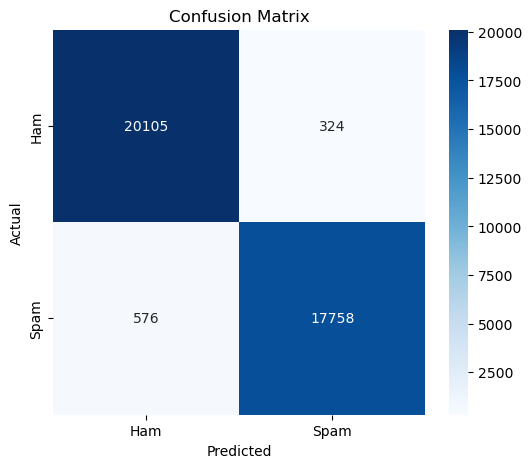

In [209]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Test the Model on New Emails

In [202]:
sample_email = [
    "Congratulations! You have gift a $1000 gift card. Click here to claim your prize."
]

sample_vector = tfidf.transform(sample_email)

prediction = perceptron.predict(sample_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam


In [203]:
sample_email = [
    "Hi John, can we meet tomorrow at 10 AM to discuss the project?"
]

sample_vector = tfidf.transform(sample_email)

prediction = perceptron.predict(sample_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham


In [204]:
sample_email = "Congratulations! You have gift a $1000 gift card. Click here to claim your prize."

# Preprocess the email first
clean_email = preprocess_text(sample_email)

# Transform
sample_vector = tfidf.transform([clean_email])

# Predict
prediction = perceptron.predict(sample_vector)

print("Processed email:", clean_email)
print("Prediction:", "Spam" if prediction[0] == 1 else "Ham")

Processed email: congratulation gift gift card click claim prize
Prediction: Spam


In [207]:
score = perceptron.decision_function(sample_vector)

print(score)

[0.59798304]


# Save the Model

In [210]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [211]:
import joblib

joblib.dump(perceptron, "perceptron_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


# Final Conclusion

In this project, a Perceptron-based email classification model was developed to distinguish spam emails from legitimate (ham) emails. The dataset was first explored through exploratory data analysis, followed by text preprocessing techniques including lowercasing, removal of HTML tags, URLs, email addresses, punctuation, stopwords, and lemmatization. The cleaned text was then transformed into numerical features using the TF-IDF vectorizer.

An initial model using 5,000 unigram TF-IDF features achieved an accuracy of approximately 96.72%. Error analysis revealed that the model struggled with certain promotional spam messages because it considered individual words independently. To improve performance, the TF-IDF vectorizer was enhanced by increasing the vocabulary size to 10,000 features and including both unigrams and bigrams (`ngram_range=(1,2)`). This enabled the model to capture meaningful phrases such as "gift card", "click here", and "claim prize", resulting in improved classification performance.

The final Perceptron model achieved an accuracy of 97.68%, a precision of 98.21%, a recall of 96.86%, and an F1-score of 97.53%. These results indicate that the model effectively distinguishes spam from ham emails while maintaining a strong balance between precision and recall.

Overall, the project demonstrates that careful text preprocessing and feature engineering can substantially improve the performance of a machine learning classifier without changing the underlying learning algorithm. The final model is accurate, efficient, and suitable for automated email spam detection.
